# Phase 2 — Baselines

Three simple, no-ML baselines + a validation harness + a submission writer. Every fancier model in
Phase 3 has to beat these.

**Recap from EDA that drives the design:**
- 773 train / 3 test wells. Train CSVs include the **ground-truth `TVT`** column alongside `TVT_input`,
  so validation = predict where `TVT_input` is NaN, compare to `TVT`.
- Eval zone is always contiguous and at the tail (100%). The boundary between the last known row and the
  first eval row is the natural anchor for every baseline.
- Eval-zone fraction: median 74%, range 20–88%.
- Eval zone is truly horizontal (median 88° from vertical) — `Z` is meaningful and observed everywhere.
- |ΔTVT/ΔZ| ≈ 1.05 step-by-step (not 1.0) — horizon dips along the wellbore, so a constant `TVT − Z`
  offset is a strong but imperfect baseline.
- GR has ~25–30% NaN. Baselines here don't use GR, so we sidestep that.

**Cells:**
- §0 Setup
- §1 Sample-submission inspection
- §2 Cache train wells in memory
- §3 Validation harness
- §4 Baseline A: carry-forward
- §5 Baseline B: Z-shift
- §6 Baseline C: linear extrapolation of TVT(MD), with K-sweep
- §7 Comparison
- §8 Submission
- §9 Findings & Phase-3 hooks

## 0. Setup

In [13]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
TRAIN_DIR = DATA / 'train'
TEST_DIR  = DATA / 'test'
CACHE_DIR = ROOT / 'cache';        CACHE_DIR.mkdir(exist_ok=True)
SUB_DIR   = ROOT / 'submissions';  SUB_DIR.mkdir(exist_ok=True)

# Schema constants (confirmed from notebook 01)
COL_MD, COL_X, COL_Y, COL_Z = 'MD', 'X', 'Y', 'Z'
COL_GR = 'GR'
COL_TVT_INPUT = 'TVT_input'  # masked input (NaN in eval zone)
COL_TVT       = 'TVT'        # ground truth (train only)

print(f'Project root: {ROOT}')
print(f'Cache dir:    {CACHE_DIR}')
print(f'Submissions:  {SUB_DIR}')

Project root: /home/gokhuu/portfolio/ROGII-Wellbore
Cache dir:    /home/gokhuu/portfolio/ROGII-Wellbore/cache
Submissions:  /home/gokhuu/portfolio/ROGII-Wellbore/submissions


## 1. Sample submission — lock the output format

Run this once. The row order in `sample_submission.csv` is canonical: predict every row it lists, in that order.

In [14]:
ss = pd.read_csv(DATA / 'sample_submission.csv')
print(f'shape: {ss.shape}')
print(f'columns: {list(ss.columns)}')
print(ss.head(8))

ID_COL, VAL_COL = ss.columns[0], ss.columns[1]

# Confirm the {wellname}_{row_index} convention
ss_split = ss[ID_COL].str.rsplit('_', n=1, expand=True)
ss_split.columns = ['well', 'row_idx_str']
ss_split['row_idx'] = pd.to_numeric(ss_split['row_idx_str'], errors='coerce').astype('Int64')
print(f'\nWells in sample_submission: {ss_split["well"].nunique()}')
print(ss_split.groupby('well').size())

shape: (14151, 2)
columns: ['id', 'tvt']
              id  tvt
0  000d7d20_1442  0.0
1  000d7d20_1443  0.0
2  000d7d20_1444  0.0
3  000d7d20_1445  0.0
4  000d7d20_1446  0.0
5  000d7d20_1447  0.0
6  000d7d20_1448  0.0
7  000d7d20_1449  0.0

Wells in sample_submission: 3
well
000d7d20    3836
00bbac68    6014
00e12e8b    4301
dtype: int64


## 2. Cache all train wells in memory

Loads every train horizontal-well CSV into one DataFrame with `well` and `row_idx` columns. Pickles the
result so re-runs are instant. First run takes ~30–60s.

**Important columns added by this loader:** `well` (string) and `row_idx` (int — the row's position
*within its own well's CSV*, needed later for the submission row id).

In [15]:
TRAIN_CACHE = CACHE_DIR / 'train_wells.pkl'

def load_train_wells(force_reload: bool = False) -> pd.DataFrame:
    if TRAIN_CACHE.exists() and not force_reload:
        df = pd.read_pickle(TRAIN_CACHE)
        print(f'Loaded cache: {df.shape} from {TRAIN_CACHE.name}')
        return df
    print('Reading 773 train CSVs...')
    files = sorted(TRAIN_DIR.glob('*__horizontal_well.csv'))
    frames = []
    for f in files:
        well = f.name.replace('__horizontal_well.csv', '')
        d = pd.read_csv(f)
        d['well'] = well
        d['row_idx'] = np.arange(len(d), dtype=np.int32)
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df.to_pickle(TRAIN_CACHE)
    print(f'Cached: {df.shape} -> {TRAIN_CACHE.name}')
    return df

train_df = load_train_wells()
print(f'\nMemory: ~{train_df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'Wells:  {train_df["well"].nunique()}')
train_df.head()

Loaded cache: (5092255, 15) from train_wells.pkl

Memory: ~631 MB
Wells:  773


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well,row_idx
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20,0
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20,1
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20,2
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20,3
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20,4


## 3. Validation harness

**Centerpiece of the notebook.** Every baseline (and every Phase-3 model) plugs in here.

**Contract:** `predict_fn(well_df) -> np.ndarray` of length `len(well_df)`. Predictions for *every* row,
known and eval. The harness extracts the eval rows and scores them. Forcing a full-length output keeps the
API uniform — some baselines use known TVT_input internally (e.g. carry-forward), others don't.

**Pooled vs per-well RMSE.** The leaderboard scores `sqrt(mean((pred - truth)^2))` over *all* eval rows in
*all* test wells, so a long well contributes more rows than a short one. Mean-of-per-well-RMSEs weights every
well equally — different metric, different ranking. We report both, but optimize for pooled.

In [16]:
def evaluate_baseline(
    predict_fn,
    train_df: pd.DataFrame,
    label: str = '',
) -> tuple[pd.DataFrame, float]:
    """Score a baseline against simulated-eval-zone ground truth.

    Returns:
        per_well: DataFrame, one row per well, columns [well, rmse, n_eval, mae, max_err].
        pooled:   sqrt(SSE_total / N_total) across all eval rows. Mirrors leaderboard scoring.
    """
    rows = []
    sse_total = 0.0
    n_total   = 0
    for well, g in train_df.groupby('well', sort=False):
        eval_mask = g[COL_TVT_INPUT].isna().values
        if not eval_mask.any():
            continue
        truth = g.loc[eval_mask, COL_TVT].values
        pred  = np.asarray(predict_fn(g), dtype=float)
        if pred.shape[0] != len(g):
            raise ValueError(
                f'predict_fn returned {pred.shape[0]} preds for well {well} of length {len(g)}'
            )
        diff = pred[eval_mask] - truth
        sq = diff ** 2
        rows.append({
            'well':    well,
            'rmse':    float(np.sqrt(sq.mean())),
            'n_eval':  int(eval_mask.sum()),
            'mae':     float(np.abs(diff).mean()),
            'max_err': float(np.abs(diff).max()),
        })
        sse_total += float(sq.sum())
        n_total   += int(len(sq))
    res = pd.DataFrame(rows)
    pooled = float(np.sqrt(sse_total / n_total)) if n_total else float('nan')
    if label:
        print(
            f'{label:30s}  pooled RMSE = {pooled:8.3f}   '
            f'per-well: median={res["rmse"].median():7.2f}, '
            f'mean={res["rmse"].mean():7.2f}, '
            f'p90={res["rmse"].quantile(.9):7.2f}, '
            f'max={res["rmse"].max():7.2f}'
        )
    return res, pooled

## 4. Baseline A — carry-forward

Predict `TVT_eval = TVT_boundary` for every eval row — the last known TVT, carried forward unchanged.
Pure floor: assumes the well stays at the same TVT for the entire eval zone. Every other baseline must
beat this.

In [17]:
def predict_carry_forward(g: pd.DataFrame) -> np.ndarray:
    # ffill propagates the last non-NaN forward; bfill is defensive against any leading NaN
    # (shouldn't happen given EDA — eval is always at tail — but cheap insurance).
    return g[COL_TVT_INPUT].ffill().bfill().values.astype(float)

res_A, rmse_A = evaluate_baseline(predict_carry_forward, train_df, 'A. carry-forward')

A. carry-forward                pooled RMSE =   15.910   per-well: median=  10.67, mean=  12.81, p90=  22.97, max=  70.64


## 5. Baseline B — Z-shift projection

Anchor at the boundary, assume the geological reference horizon is **flat** from there onward:

```
offset      = TVT_boundary - Z_boundary       (computed at the last known row)
TVT_eval[i] = Z_eval[i] + offset              (for every eval row i)
```

Should beat A whenever the well changes elevation through the eval zone (which is always — the lateral
isn't perfectly horizontal). The 5% dip drift we found in EDA means this baseline accumulates error toward
the end of the eval zone, but should still be a clear win over A.

In [18]:
def predict_z_shift(g: pd.DataFrame) -> np.ndarray:
    pred = g[COL_TVT_INPUT].values.astype(float).copy()
    eval_mask = np.isnan(pred)
    if not eval_mask.any():
        return pred
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0:
        # Degenerate: no anchor. Fall back to Z (better than NaN).
        return g[COL_Z].values.astype(float)
    last_k = known_idx[-1]
    z_vals = g[COL_Z].values
    offset = pred[last_k] - z_vals[last_k]
    pred[eval_mask] = z_vals[eval_mask] + offset
    return pred

res_B, rmse_B = evaluate_baseline(predict_z_shift, train_df, 'B. Z-shift')

B. Z-shift                      pooled RMSE =  111.319   per-well: median=  94.68, mean=  97.35, p90= 150.74, max= 263.35


## 6. Baseline C — linear extrapolation of TVT(MD)

Fit a line to the last K known rows of `TVT_input` against `MD`, extrapolate over the eval zone. Captures
local trend without leaning on `Z`. K is a hyperparameter — small K = noisy local fit; large K = washes out
recent build-curve dynamics. Sweep a range and pick the best by pooled RMSE.

**Why interesting separate from B:** Z-shift uses *observed* Z in the eval zone but assumes flat horizon.
Linear-MD captures *extrapolated TVT trend* (closer to true horizon dip) but ignores observed Z. Their
comparison tells us whether observed-Z or extrapolated-trend is more informative — directly shapes Phase 3.

In [19]:
def make_linear_extrap_md(K: int):
    """Returns a predict_fn that fits a line on the last K known TVT_input rows."""
    def predict(g: pd.DataFrame) -> np.ndarray:
        pred = g[COL_TVT_INPUT].values.astype(float).copy()
        eval_mask = np.isnan(pred)
        if not eval_mask.any():
            return pred
        known_idx = np.where(~eval_mask)[0]
        if len(known_idx) < 2:
            # Not enough points to fit a line — fall back to carry-forward.
            if len(known_idx) == 1:
                pred[eval_mask] = pred[known_idx[0]]
            return pred
        idx_fit = known_idx[-K:] if len(known_idx) >= K else known_idx
        x_fit = g[COL_MD].values[idx_fit]
        y_fit = pred[idx_fit]
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        pred[eval_mask] = slope * g[COL_MD].values[eval_mask] + intercept
        return pred
    return predict

K_sweep = [20, 50, 100, 200, 500, 1000]
K_results = {}
for K in K_sweep:
    res, rmse = evaluate_baseline(make_linear_extrap_md(K), train_df, f'C linear K={K}')
    K_results[K] = (res, rmse)

best_K = min(K_results, key=lambda k: K_results[k][1])
res_C, rmse_C = K_results[best_K]
print(f'\nBest K for linear MD extrapolation: K={best_K}  ->  pooled RMSE {rmse_C:.3f}')

C linear K=20                   pooled RMSE =  107.771   per-well: median=  37.71, mean=  58.72, p90= 128.29, max=1332.39
C linear K=50                   pooled RMSE =  113.660   per-well: median=  38.01, mean=  60.70, p90= 132.29, max=1392.70
C linear K=100                  pooled RMSE =  117.286   per-well: median=  36.65, mean=  60.22, p90= 135.27, max=1437.14
C linear K=200                  pooled RMSE =  124.001   per-well: median=  35.61, mean=  59.45, p90= 130.99, max=1537.54
C linear K=500                  pooled RMSE =  162.475   per-well: median=  38.61, mean=  67.46, p90= 134.86, max=2004.13
C linear K=1000                 pooled RMSE =  393.334   per-well: median= 192.45, mean= 247.22, p90= 436.32, max=2701.63

Best K for linear MD extrapolation: K=20  ->  pooled RMSE 107.771


## 7. Comparison

Summary table, per-well RMSE distribution, head-to-head scatter, and error-vs-position curve.

In [20]:
summary = pd.DataFrame([
    {'baseline': 'A. carry-forward',
     'pooled_rmse': rmse_A,
     'median_rmse': res_A['rmse'].median(),
     'mean_rmse':   res_A['rmse'].mean(),
     'p90_rmse':    res_A['rmse'].quantile(.9),
     'max_rmse':    res_A['rmse'].max()},
    {'baseline': 'B. Z-shift',
     'pooled_rmse': rmse_B,
     'median_rmse': res_B['rmse'].median(),
     'mean_rmse':   res_B['rmse'].mean(),
     'p90_rmse':    res_B['rmse'].quantile(.9),
     'max_rmse':    res_B['rmse'].max()},
    {'baseline': f'C. linear MD (K={best_K})',
     'pooled_rmse': rmse_C,
     'median_rmse': res_C['rmse'].median(),
     'mean_rmse':   res_C['rmse'].mean(),
     'p90_rmse':    res_C['rmse'].quantile(.9),
     'max_rmse':    res_C['rmse'].max()},
]).set_index('baseline').round(2)
summary

,pooled_rmse,median_rmse,mean_rmse,p90_rmse,max_rmse
baseline,,,,,
A. carry-forward,15.91,10.67,12.81,22.97,70.64
B. Z-shift,111.32,94.68,97.35,150.74,263.35
C. linear MD (K=20),107.77,37.71,58.72,128.29,1332.39


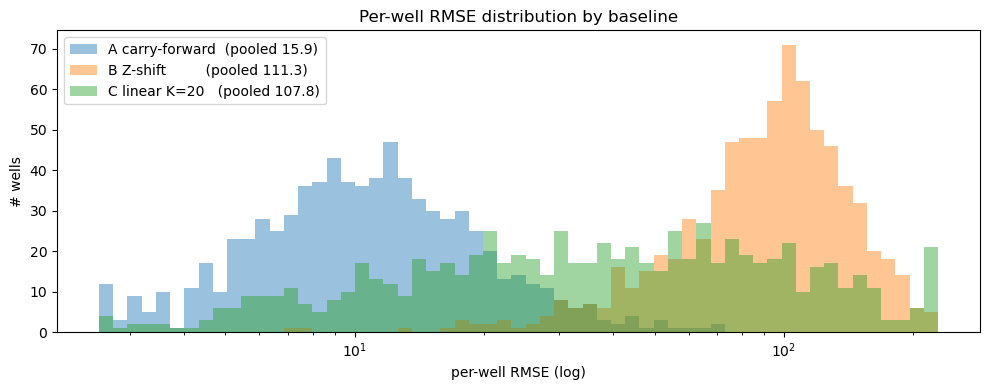

In [21]:
# Per-well RMSE distribution. Log x because RMSEs span orders of magnitude.
all_rmses = np.concatenate([res_A['rmse'].values, res_B['rmse'].values, res_C['rmse'].values])
all_rmses = all_rmses[all_rmses > 0]
lo, hi = np.quantile(all_rmses, [0.005, 0.995])
bins = np.logspace(np.log10(max(0.01, lo)), np.log10(hi), 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(res_A['rmse'].clip(bins[0], bins[-1]), bins=bins, alpha=0.45, label=f'A carry-forward  (pooled {rmse_A:.1f})')
ax.hist(res_B['rmse'].clip(bins[0], bins[-1]), bins=bins, alpha=0.45, label=f'B Z-shift         (pooled {rmse_B:.1f})')
ax.hist(res_C['rmse'].clip(bins[0], bins[-1]), bins=bins, alpha=0.45, label=f'C linear K={best_K:<4d} (pooled {rmse_C:.1f})')
ax.set_xscale('log')
ax.set_xlabel('per-well RMSE (log)')
ax.set_ylabel('# wells')
ax.set_title('Per-well RMSE distribution by baseline')
ax.legend()
plt.tight_layout(); plt.show()

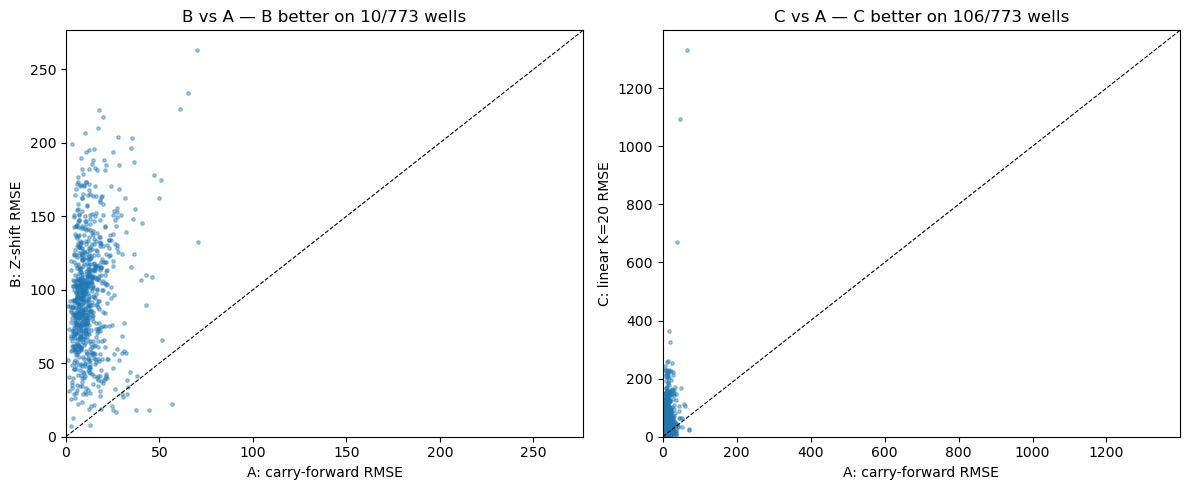

In [22]:
# Head-to-head scatter: per-well B-vs-A and C-vs-A. Below the y=x line means the column-baseline wins.
joined = (res_A.set_index('well')['rmse'].rename('A').to_frame()
          .join(res_B.set_index('well')['rmse'].rename('B'))
          .join(res_C.set_index('well')['rmse'].rename('C')))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, name, rmse in [(axes[0], 'B', 'Z-shift', rmse_B),
                             (axes[1], 'C', f'linear K={best_K}', rmse_C)]:
    ax.scatter(joined['A'], joined[col], s=6, alpha=0.4)
    lim_hi = max(joined['A'].max(), joined[col].max()) * 1.05
    ax.plot([0, lim_hi], [0, lim_hi], 'k--', lw=0.8)
    ax.set_xlim(0, lim_hi); ax.set_ylim(0, lim_hi)
    ax.set_xlabel('A: carry-forward RMSE'); ax.set_ylabel(f'{col}: {name} RMSE')
    n_wins = int((joined[col] < joined['A']).sum())
    ax.set_title(f'{col} vs A — {col} better on {n_wins}/{len(joined)} wells')
plt.tight_layout(); plt.show()

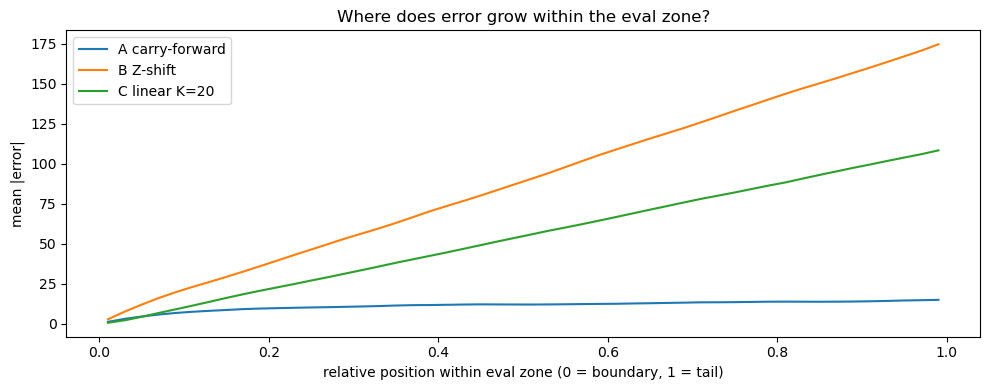

In [23]:
# Error vs relative position within the eval zone. 0 = boundary, 1 = well tail.
# Tells us whether error grows with distance-from-boundary, plateaus, or stays flat.
def error_curve(predict_fn, train_df, n_bins=50):
    rels, errs = [], []
    for well, g in train_df.groupby('well', sort=False):
        eval_mask = g[COL_TVT_INPUT].isna().values
        if not eval_mask.any():
            continue
        n_eval = int(eval_mask.sum())
        rel = np.arange(n_eval) / max(1, n_eval - 1)
        pred = np.asarray(predict_fn(g), dtype=float)[eval_mask]
        truth = g.loc[eval_mask, COL_TVT].values
        rels.append(rel); errs.append(np.abs(pred - truth))
    rels = np.concatenate(rels); errs = np.concatenate(errs)
    edges = np.linspace(0, 1, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    means = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (rels >= edges[i]) & (rels < edges[i+1])
        if m.any():
            means[i] = errs[m].mean()
    return centers, means

fig, ax = plt.subplots(figsize=(10, 4))
for fn, lbl in [(predict_carry_forward, 'A carry-forward'),
                (predict_z_shift,       'B Z-shift'),
                (make_linear_extrap_md(best_K), f'C linear K={best_K}')]:
    x, y = error_curve(fn, train_df)
    ax.plot(x, y, label=lbl)
ax.set_xlabel('relative position within eval zone (0 = boundary, 1 = tail)')
ax.set_ylabel('mean |error|')
ax.set_title('Where does error grow within the eval zone?')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Generate submission

Pick the best baseline by pooled RMSE, predict on the 3 test wells, write a CSV that matches
`sample_submission.csv` exactly.

In [24]:
BASELINES = {
    'A_carry_forward':       (predict_carry_forward,            rmse_A),
    'B_z_shift':             (predict_z_shift,                  rmse_B),
    f'C_linear_K{best_K}':   (make_linear_extrap_md(best_K),    rmse_C),
}
best_name = min(BASELINES, key=lambda k: BASELINES[k][1])
best_fn, best_rmse_val = BASELINES[best_name]
print(f'Chosen baseline: {best_name}  (validation pooled RMSE = {best_rmse_val:.3f})')

# Predict on each test well, key by '{well}_{row_idx}'.
predictions: dict[str, float] = {}
test_files = sorted(TEST_DIR.glob('*__horizontal_well.csv'))
for f in test_files:
    well = f.name.replace('__horizontal_well.csv', '')
    g = pd.read_csv(f)
    g['row_idx'] = np.arange(len(g))
    pred = best_fn(g)
    eval_mask = g[COL_TVT_INPUT].isna().values
    for i in np.where(eval_mask)[0]:
        predictions[f'{well}_{i}'] = float(pred[i])
print(f'Generated {len(predictions)} predictions across {len(test_files)} test wells')

# Map predictions onto sample_submission row order — this is the canonical format.
out = ss.copy()
out[VAL_COL] = out[ID_COL].map(predictions)
n_missing = int(out[VAL_COL].isna().sum())
print(f'Missing predictions: {n_missing} / {len(out)}')

if n_missing == 0:
    sub_path = SUB_DIR / f'02_{best_name}.csv'
    out.to_csv(sub_path, index=False)
    print(f'Saved: {sub_path}')
    print(out.head())
else:
    print('Sample missing row_ids (investigate before submitting):')
    print(out[out[VAL_COL].isna()].head(10))
    print('\nLikely cause: test-well eval-row detection differs from sample_submission expectations.')

Chosen baseline: A_carry_forward  (validation pooled RMSE = 15.910)
Generated 14151 predictions across 3 test wells
Missing predictions: 0 / 14151
Saved: /home/gokhuu/portfolio/ROGII-Wellbore/submissions/02_A_carry_forward.csv
              id       tvt
0  000d7d20_1442  11747.37
1  000d7d20_1443  11747.37
2  000d7d20_1444  11747.37
3  000d7d20_1445  11747.37
4  000d7d20_1446  11747.37


## 9. Findings & Phase-3 hooks

*Fill in after running the baselines.*

- **Best baseline:** ___, pooled RMSE ___
- **Carry-forward (A):** pooled RMSE ___
- **Z-shift (B):** pooled RMSE ___; beats A on ___ / 773 wells
- **Linear MD K=___ (C):** pooled RMSE ___; beats A on ___ / 773 wells
- **Where does error concentrate?** (uniform across eval zone / grows with distance / spikes at tail / etc.)
- **Which wells fail badly under all three?** (record their well IDs — Phase 3 will need to handle them)

**Phase 3 directions, in roughly increasing complexity:**
1. **Z-shift with locally-fit dip.** B assumes flat horizon. Fit `dip = d(TVT - Z)/d(MD)` from the last
   K known rows, propagate so the offset evolves along MD instead of staying constant. Cheap, likely a
   clear win over plain B.
2. **Predict surface elevations from train-only supervision.** Train a regressor on `(X, Y, Z, MD, GR)`
   -> surface columns (`ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA`) using the train data, then derive TVT from
   the predicted surface position at each test row. Uses train-only surface info as auxiliary supervision.
3. **Per-well GR<->typewell correlation.** Normalize lateral and typewell GR per-well; slide the lateral-GR
   window over the typewell GR-vs-TVT curve; take the best-matching position as the TVT estimate. The
   classic geosteering move.
4. **Global ML model.** XGBoost/LightGBM on engineered features per row: distance-from-boundary, local GR
   stats, trajectory derivatives, surface predictions, etc. Cross-well validation via grouped k-fold.
5. **Sequence models.** LSTM/Transformer over each well, encoder over the typewell, attention over the
   GR-correlation match. Defer until 1-4 are exhausted.

**Reusable pieces from this notebook:**
- `evaluate_baseline(predict_fn, train_df)` is the unit of measurement — every Phase-3 model plugs in here.
- `train_df` cache means cross-well experiments don't pay the 30s reload cost.
- The submission block in §8 only changes its `predict_fn` — same template across notebooks.